#Libraries


In [ ]:
%pip install networkx matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime, timedelta
import random
import csv
import plotly.express as px

# The Data

Import planned schedule flight

In [ ]:
df_current_plan = pd.read_csv('https://raw.githubusercontent.com/Gurobi/modeling-examples/master/aviation_planning/data/flight_rotations_2006-07-01.csv')

### Structure the input.
df_current_plan['start_time'] = pd.to_datetime(df_current_plan['start_time'], format= '%H:%M')
df_current_plan['start_time'] = df_current_plan['start_time'].dt.time
df_current_plan['end_time'] = pd.to_datetime(df_current_plan['end_time'], format = '%H:%M')
df_current_plan['end_time'] = df_current_plan['end_time'].dt.time
df_current_plan['duration'] = pd.to_datetime(df_current_plan['duration'], format = '%H:%M')
df_current_plan['duration'] = df_current_plan['duration'].dt.time
### Show the table
df_current_plan

,flight,date,aircraft,ori,des,start_time,end_time,duration
0,1,7/1/06,TranspCom#1,CDG,ORY,00:00:00,00:30:00,00:30:00
1,73,7/1/06,TranspCom#3,ORY,CDG,00:00:00,00:30:00,00:30:00
2,2,7/1/06,TranspCom#2,CDG,ORY,00:20:00,00:50:00,00:30:00
3,74,7/1/06,TranspCom#4,ORY,CDG,00:20:00,00:50:00,00:30:00
4,75,7/1/06,TranspCom#1,ORY,CDG,00:40:00,01:10:00,00:30:00
...,...,...,...,...,...,...,...,...
603,142,7/1/06,TranspCom#4,ORY,CDG,23:00:00,23:30:00,00:30:00
604,143,7/1/06,TranspCom#1,ORY,CDG,23:20:00,23:50:00,00:30:00
605,71,7/1/06,TranspCom#3,CDG,ORY,23:20:00,23:50:00,00:30:00
606,144,7/1/06,TranspCom#2,ORY,CDG,23:40:00,00:10:00,00:30:00


Compute the total flights, total airports and aircrafts on the schedule

In [ ]:
flights = df_current_plan['flight'].unique()
airports = df_current_plan['ori'].unique() + df_current_plan['des'].unique()
aircrafts = df_current_plan['aircraft'].unique()

print("There are", len(flights),"flights, ",len(airports),"airports and",len(aircrafts),"aircrafts on the schedule.")

There are 608 flights,  35 airports and 85 aircrafts on the schedule.


Visualize the network

In [ ]:
from IPython.display import Image, display
import networkx as nx
from networkx.drawing.nx_agraph import graphviz_layout
from networkx.drawing.nx_agraph import to_agraph

### Arcs and Paths
arcs = list(df_current_plan[['ori','des']].itertuples(index=False, name=None))

G = nx.MultiDiGraph()
G.add_edges_from(arcs)

top_airports = [i for (i,j) in sorted(G.degree, key=lambda x: x[1], reverse=True)[:35]]
G = G.subgraph(top_airports)

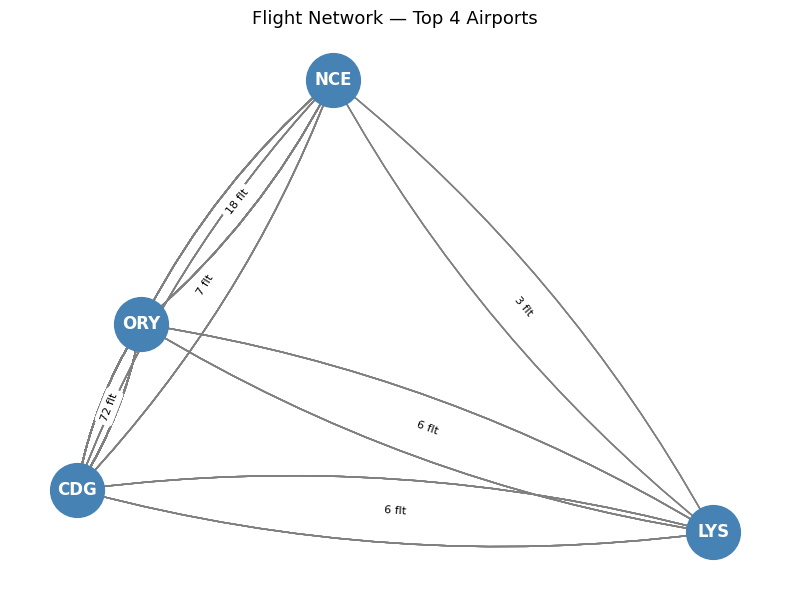

The reduced data has 222 flights between 4 airports operated with 21 aircrafts


In [ ]:
### Viualize the network (optional to activate)
arcs = list(df_current_plan[['ori','des']].itertuples(index=False, name=None)) # store the origin-destination pairs of all the flights

n_airports = 4 # specify how many airports to pick

G = nx.MultiDiGraph() # create an empty directed graph
G.add_edges_from(arcs) # add the origin-destination pairs to the graph as directed edges

top_airports = [i for (i,j) in sorted(G.degree, key=lambda x: x[1], reverse=True)[:n_airports]] # pre-select top airports by their degree

G = G.subgraph(top_airports) # reduce the graph to just the top few airports

# reduce the current plan dataframe to just the top few airports
df_current_plan = df_current_plan[df_current_plan['ori'].isin(top_airports)]
df_current_plan = df_current_plan[df_current_plan['des'].isin(top_airports)]

# visualize the network
fig, ax = plt.subplots(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)

edge_counts = {}
for u, v in G.edges():
    edge_counts[(u, v)] = edge_counts.get((u, v), 0) + 1
nx.draw_networkx_nodes(G, pos, node_size=1500, node_color='steelblue', ax=ax)
nx.draw_networkx_labels(G, pos, font_color='white', font_weight='bold', ax=ax)
nx.draw_networkx_edges(
    G, pos,
    edge_color='gray',
    arrows=True,
    arrowsize=20,
    connectionstyle='arc3,rad=0.1',   # slight curve to show bidirectional arcs
    ax=ax
)
# Annotate each edge with flight count
edge_labels = {(u, v): f"{cnt} flt" for (u, v), cnt in edge_counts.items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=ax)
ax.set_title(f"Flight Network — Top {n_airports} Airports", fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

flights = df_current_plan['flight'].unique()
aircrafts = df_current_plan['aircraft'].unique()
airports = set(df_current_plan['ori'].unique()+df_current_plan['des'].unique())

print("The reduced data has",len(flights),"flights between",len(airports),"airports operated with",len(aircrafts),"aircrafts")

Lists

In [ ]:
flight_origin = df_current_plan.set_index('flight')['ori'].to_dict()
flight_dest = df_current_plan.set_index('flight')['des'].to_dict()
flight_start_time = df_current_plan.set_index('flight')['start_time'].to_dict()
flight_end_time = df_current_plan.set_index('flight')['end_time'].to_dict()

Add source and sink

In [ ]:
df_starting_positions = pd.read_csv('https://raw.githubusercontent.com/Gurobi/modeling-examples/master/aviation_planning/data/starting_positions.csv')
aircrafts_startpositions_airc = df_starting_positions.set_index('aircraft')['airport'].to_dict()

df_ending_positions = pd.read_csv('https://raw.githubusercontent.com/Gurobi/modeling-examples/master/aviation_planning/data/ending_positions.csv')
aircrafts_endpositions_airc = df_ending_positions.set_index('aircraft')['airport'].to_dict()

Flight Iterinaties

In [ ]:
df_iterinaries = pd.read_csv('https://raw.githubusercontent.com/Gurobi/modeling-examples/master/aviation_planning/data/flight_iterinaries.csv')
df_iterinaries['total_cost'] = df_iterinaries['cost']*df_iterinaries['n_pass']
flight_revenue = df_iterinaries.groupby(['flight'])['total_cost'].agg('sum').to_dict()
flight_n_pass = df_iterinaries.groupby(['flight'])['n_pass'].agg('sum').to_dict()
df_iterinaries

,cost,n_pass,flight,total_cost
0,137.5,24.0,4296.0,3300.0
1,137.5,33.0,4296.0,4537.5
2,137.5,24.0,4296.0,3300.0
3,137.5,44.0,4296.0,6050.0
4,137.5,35.0,4295.0,4812.5
...,...,...,...,...
1925,200.0,15.0,2620.0,3000.0
1926,250.0,6.0,2609.0,1500.0
1927,250.0,4.0,2609.0,1000.0
1928,325.0,16.0,5125.0,5200.0


Flight-to-flight transitions for each aircraft

In [ ]:
from ipywidgets import interact, interactive, fixed, interact_manual

aircraft_flights = df_current_plan.groupby(['aircraft']).apply(lambda x: x['flight'].tolist()).to_dict()
flight_arcs_for_each_aircraft = {}
deltaplus_flightarcs = {}
deltaminus_flightarcs = {}
for a in aircraft_flights:
    aircraft_flights[a] += ['source_%s'%a,'sink_%s'%a]
    flight_origin['source_%s'%a] = aircrafts_endpositions_airc[a]
    flight_dest['source_%s'%a] = aircrafts_startpositions_airc[a]
    flight_origin['sink_%s'%a] = aircrafts_endpositions_airc[a]
    flight_dest['sink_%s'%a] = aircrafts_startpositions_airc[a]

    flight_start_time['source_%s'%a] = datetime.strptime('0:0', '%H:%M').time()
    flight_end_time['source_%s'%a] = datetime.strptime('0:0', '%H:%M').time()

    flight_start_time['sink_%s'%a] = datetime.strptime('23:59', '%H:%M').time()
    flight_end_time['sink_%s'%a] = datetime.strptime('23:59', '%H:%M').time()

    flight_arcs_for_each_aircraft[a] = []
    deltaplus_flightarcs[a] = {f: [] for f in aircraft_flights[a]}
    deltaminus_flightarcs[a] = {f: [] for f in aircraft_flights[a]}

    for f1 in aircraft_flights[a]:
        for f2 in aircraft_flights[a]:
            if f1!=f2 and flight_end_time[f1] < flight_start_time[f2] and flight_dest[f1] == flight_origin[f2]:
                flight_arcs_for_each_aircraft[a].append((f1,f2))
                deltaplus_flightarcs[a][f1].append(f2)
                deltaminus_flightarcs[a][f2].append(f1)
            # allow to connect source and target directly for the case that aircraft is not used at all
            elif str(f1).startswith('source') and str(f2).startswith('sink'):
                flight_arcs_for_each_aircraft[a].append((f1,f2))
                deltaplus_flightarcs[a][f1].append(f2)
                deltaminus_flightarcs[a][f2].append(f1)

In [ ]:
# packages needed to visualize the DAG
# uncomment the whole cell in case of troubles
!apt install libgraphviz-dev
!pip install pygraphviz

def visualize_aircraft_network(x):
    G = nx.DiGraph()
    G.add_edges_from(flight_arcs_for_each_aircraft[x])
    plt.figure(figsize=(20,14))
    A_graph = to_agraph(G)
    A_graph.layout('dot')
    display(A_graph)
    plt.show()

interact(visualize_aircraft_network, x=aircraft_flights.keys())

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libgraphviz-dev is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


interactive(children=(Dropdown(description='x', options=('A318#1', 'A318#2', 'A318#3', 'A318#4', 'A318#5', 'A3…

<function __main__.visualize_aircraft_network(x)>

# **Optimization Model**

Assumption

The following are some key assumptions.
- All airports have the same level of disruption, which is across the entire day.
- We assume that we know ahead of time the level of disruption at all airports.
- We ignore crew scheduling and maintainance issues; though this model can be extended for larger inputs with a commercial Gurobi licence.
- We do not consider how other airlines may react to the disruption.



### Input Parameters

Let us now define the input parameters and notations used for creating the model. The subscript $a$ will be used to denote each aircraft, $f$ for each flight, and $i$ for each airport.


- $N$: set of all airports
- $a$: set of all aircrafts
- $f$: set of all flights
- $f_a$: set of flights operated by aircraft $a$ in the current plan
- $e_a$: set of feasible flight-to-flight transitions for aircraft $a$
- $r_f$: revenue ($\$$) from operating flight $f$
- $(o_f,d_f)$: origin, destination airports for flight $f$
- $(C^{arr}_i,C^{dep}_i)$: maximum number of arrivals and departures in airport $i$
- $\alpha$: level of disruption

The following code loads the Gurobi python package and initiates the optimization model.
The value of $\alpha$ is set to $50\%$.


In [ ]:
%pip install gurobipy
import gurobipy as gp
from gurobipy import GRB
model = gp.Model("airline_disruption")

N = G.nodes()

Restricted license - for non-production use only - expires 2027-11-29


### Decision Variables

We now define the decision variables.
In our model, we want to do two things: pick flights to be operated by each aircraft and construct a route for each aircraft.
The following notation is used to model these decision variables.


$x_{a,f}$: $1$, if aircraft $a$ operates flight $f$; $0$, otherwise

$y_{a,f_1,f_2}$: $1$, if aircraft $a$ operates flight $f_2$ immediately after flight $f_1$; $0$, otherwise

We will now add the variables to the Gurobi model using the addVar function.

In [ ]:
x, y = {}, {}
for a in aircrafts:
    for f in aircraft_flights[a]:
        x[a,f] = model.addVar(name="x_%s,%s"%(a,f), vtype=GRB.BINARY)

    for (f1,f2) in flight_arcs_for_each_aircraft[a]:
        y[a,f1,f2] = model.addVar(name="y_%s,%s,%s"%(a,f1,f2), vtype=GRB.BINARY)

model.update()


### Set the Objective: minimize the revenue from cancelled flights

<!-- Next, we will define the objective function: we want to maximizing the **net revenue**. The revenue from sales in each region is calculated by the price of an avocado in that region multiplied by the quantity sold there. There are two types of costs incurred: the wastage costs for excess unsold avocados and the cost of transporting the avocados to the different regions.

The net revenue is the sales revenue subtracted by the total costs incurred. We assume that the purchase costs are fixed and are not incorporated in this model. -->

Our goal is to **minimize** the total **lost revenue** from the cancelled flights.
We capture this objective as a function of the decision variables.
Note that a flight is cancelled if $x_{a,f}$ is set to $0$.
The revenue lost from the flight is given by $(1-x_{a,f}) * r_f$.
Hence, the overall lost revenue across all aircrafts and cancelled flights is given by,


<!-- \begin{aligned}
\textrm{Maximize } \ \sum_{f \in flights} \ \sum_{a \in aircrafts} \ x_{a,f} * r_f
\end{aligned} -->

\begin{aligned}
\textrm{Minimize } \ \sum_{a \in aircrafts} \ \sum_{f \in F_a} \ (1-x_{a,f}) * r_f
\end{aligned}

We now add this objective function to the model using the setObjective function.



In [ ]:
objective = gp.quicksum((1-x[a,f])*flight_revenue[f] for a in aircrafts for f in aircraft_flights[a] if f in flight_revenue) # operating cost
model.setObjective(objective, sense=GRB.MINIMIZE)

### Constraint #1: construct each aircraft's flight path


An aircraft begins the day from its starting airport (source) and ends the day at its final airport (sink). Its route during the day is constructed using the **y** decision variables.

We do this by considering three cases for each aircraft: its starting flight, an intermediary flight, and its ending flight.

When a flight leaves its starting airport, we ensure that it can leave exactly once.
The flights in the set $\delta^+(source_a)$ gives the set of all candidate "first-flights" for the aircraft.
We ensure that exactly one of these flights is taken using the following equality for each aircraft $a$.

\begin{aligned}
\sum_{f' \in \delta^+(source_a)} y_{a,source_a,f'} &= 1
\end{aligned}

Similarly, a flight arrives at its final airport, we ensure that it enters the airport exactly once.
The flights in the set $\delta^-(sink_a)$ gives the set of all candidate "last-flights" for the aircraft, and we ensure that exactly one of these flights is taken.

\begin{aligned}
\sum_{f' \in \delta^-(sink_a)} y_{a,f',sink_a} &= 1
\end{aligned}

For every intermediary flight $f$ in $F_a$ (that is neither the starting nor the ending flight), we ensure that the number of preceding and succeeding flights are the same. This is necessary to ensure the continuity of the flight path.
The following constraints are for each aircraft $a$ and  intermediary flight $f$ in $F_a$.

\begin{aligned}
\sum_{f' \in \delta^+(f)} y_{a,f,f'} &= \sum_{f' \in \delta^-(i)} y_{a,f',f}
\end{aligned}

In optimization modeling, these types of constraints are called **flow-balance** constraints.
These are used to model many famous problems such as shortest path, maximum flow problem, and the traveling salesman problem. Read more [here](https://web.mit.edu/15.053/www/AMP-Chapter-08.pdf).
The following code adds these constraints to the model one at a time.

In [ ]:
for a in aircrafts:
    model.addConstr(sum(y[a,'source_%s'%a,f2] for f2 in deltaplus_flightarcs[a]['source_%s'%a]) == 1)
    model.addConstr(sum(y[a,f1,'sink_%s'%a] for f1 in deltaminus_flightarcs[a]['sink_%s'%a]) == 1)
    for f in aircraft_flights[a]:
        if str(f)[0] != 's':
            model.addConstr(sum(y[a,f,f2] for f2 in deltaplus_flightarcs[a][f]) == sum(y[a,f1,f] for f1 in deltaminus_flightarcs[a][f]))

### Constraint #2: a flight is operated only if it is traversed by an aircraft

Next, we make sure that a flight $f$ is operated by an aircraft $a$ only if $f$ is in the route taken by $a$.
The quantity $\sum_{f' \in \delta^+(f)} y_{a,f,f'}$ gives us the number of arcs that leave flight $f$; there can be either $0$ arcs or $1$ arc.
If this quantity is $0$, then aircraft $a$ does not traverse flight $f$, and we set $x_{a,f}$ to be $0$.
This constraint can be mathematically expressed by the following inequality for each aircraft $a$ and flight $f$ in $F_a$

\begin{aligned}  
x_{a,f} &\leq \sum_{f'\ \textrm{in }\ \delta^+(f)} y_{a,f,f'}
\end{aligned}

Let us now add these constraints to the model.


In [ ]:
for a in aircrafts:
    for f in aircraft_flights[a]:
        model.addConstr(x[a,f] <= sum(y[a,f,f2] for f2 in deltaplus_flightarcs[a][f])) # flight f is chosen only if it is traversedimport gurobipy as gp

### Constraint #3: maximum limit on the number of arrivals and departures from the airports

Finally, we add the airport capacity constraints.
For each airport, we know the total number of arrivals and departures on a regular day.
However, on the disruption day, only a fraction of flights can land and take-off, given by the parameters $\alpha$.
For example, if $\alpha = 0.5$, only half the flights can land or take-off.
This condition can be mathematically expressed using the following inequalities for every airport $i$,

\begin{aligned}
\sum_{\textrm{aircraft a}} \ \sum_{\textrm{flight }f \textrm{ that arrives at $i$}} x_{a,f} &\leq C^{arr}_{i} * \alpha \quad  \forall \ \textrm{airport } i, \\
\sum_{\textrm{aircraft a}} \ \sum_{\textrm{flight }f \textrm{ that departs from $i$}} x_{a,f} &\leq C^{dep}_{i} *\alpha \quad  \forall \ \textrm{airport } i.
\end{aligned}

The left hand side of the inequalities counts the total number of flights that land or take-off at the airports, and the right hand side sets the maximum limits.
As extreme cases, setting $\alpha  = 0$ implies that there is a complete shut-down of the airports, and $\alpha = 1$ implies that there is no disruption.

We can add these constraints to the model, with a default values set to $0.5$. Later in the notebook, we see how the disruption parameter affects the optimal flight plan.


In [ ]:
alpha = .5

for i in N:
    total_departures = len([f for a in aircrafts for f in aircraft_flights[a] if flight_origin[f] == i])
    total_arrivals = len([f for a in aircrafts for f in aircraft_flights[a] if flight_dest[f] == i])

    model.addConstr(sum(x[a,f] for a in aircrafts for f in aircraft_flights[a] if flight_origin[f] == i) <= alpha*total_departures)
    model.addConstr(sum(x[a,f] for a in aircrafts for f in aircraft_flights[a] if flight_dest[f] == i) <= alpha*total_arrivals)


### Solution and Optimal Solution

In [ ]:
model.optimize()

operated_flights = {a: [f for f in aircraft_flights[a] if x[a,f].X > .5 if str(f)[0] != 's'] for a in aircrafts}

print("\nNet revenue total loss: $",round(model.objVal/10**6,2),'million')
print("Optimal number of flights served:",sum(len(operated_flights[a]) for a in aircrafts))
print("Optimal number of passengers transported:",sum(sum(flight_n_pass[f] for f in aircraft_flights[a] if x[a,f].X > .5) for a in aircrafts))
print("Optimal number of aircrafts utilized:",sum([1 if len(operated_flights[a]) > 0 else 0 for a in aircrafts]))

My Optimization Model, which is Pywraplp in this case, as OR-Tools are free and strong enough to solve this case study with 35 airports, compared to Gurobi it may be slower.

In [ ]:
### Full Model (Pywraplp)
%pip install ortools
%pip install ipywidgets -q
from google.colab import output
output.enable_custom_widget_manager()
from ortools.linear_solver import pywraplp
import ipywidgets as widgets
from ipywidgets import interact

N = G.nodes()

def solver_flight_planning(alpha):
  solver = pywraplp.Solver.CreateSolver('SCIP')
  solver.SuppressOutput()
#### Decision Variables
  x, y = {}, {}

  for a in aircrafts:
    for f in aircraft_flights[a]:
        x[a,f] = solver.BoolVar("x_%s,%s"%(a,f))
    for f1,f2 in flight_arcs_for_each_aircraft[a]:
      y[a,f1,f2] = solver.BoolVar("y_%s,%s,%s"%(a,f1,f2))
### Objective
  objective = solver.Sum([(1-x[a,f]) * flight_revenue[f] for a in aircrafts for f in aircraft_flights[a] if f in flight_revenue])
  solver.Minimize(objective)
### Constraints
#1: Construct each aircraft's flight path
  for a in aircrafts:
    solver.Add(sum(y[a,'source_%s'%a,f2] for f2 in deltaplus_flightarcs[a]['source_%s'%a]) == 1)
    solver.Add(sum(y[a, f1, 'sink_%s'%a] for f1 in deltaminus_flightarcs[a]['sink_%s'%a]) == 1)
    for f in aircraft_flights[a]:
      if str(f)[0] != 's':
        solver.Add(sum(y[a,f,f2] for f2 in deltaplus_flightarcs[a][f]) == sum(y[a,f1,f] for f1 in deltaminus_flightarcs[a][f]))
#2: A flight is operated only if it is traversed by an aircraft
  for a in aircrafts:
    for f in aircraft_flights[a]:
      solver.Add(x[a,f] <= sum(y[a,f,f2] for f2 in deltaplus_flightarcs[a][f]))
#3: Maximum limit on the number of arrivals and departures from the airports

  for i in N:
      total_departures = len([f for a in aircrafts for f in aircraft_flights[a] if flight_origin[f] == i])
      total_arrivals = len([f for a in aircrafts for f in aircraft_flights[a] if flight_dest[f] == i])

      solver.Add(sum(x[a,f] for a in aircrafts for f in aircraft_flights[a] if flight_origin[f] == i) <= alpha*total_departures)
      solver.Add(sum(x[a,f] for a in aircrafts for f in aircraft_flights[a] if flight_dest[f] == i) <= alpha*total_arrivals)
### Solve and Result
  status = solver.Solve()
  if status in (pywraplp.Solver.OPTIMAL, pywraplp.Solver.FEASIBLE):
      operated_flights = { a: [f for f in aircraft_flights[a] if x[a,f].solution_value() > .5 if str(f)[0] != 's'] for a in aircrafts}
      print("\nNet revenue total loss: $", round(solver.Objective().Value()/10**6, 2), 'million')
      print("Optimal number of flights served:", sum(len(operated_flights[a]) for a in aircrafts))
      print("Optimal number of passengers transported:", sum(sum(flight_n_pass[f] for f in aircraft_flights[a] if x[a,f].solution_value() > .5) for a in aircrafts))
      print("Optimal number of aircrafts utilized:", sum([1 if len(operated_flights[a]) > 0 else 0 for a in aircrafts]))
### SLIDER
print("Select disruption level at airports:")
print("0 = complete shutdown | 1 = business as usual\n")
alpha_slider = widgets.FloatSlider(
    value=0.5,
    min=0.0,
    max=1.0,
    step=0.05,
    description='Alpha:',
    continuous_update=False
)
widgets.interactive(solver_flight_planning, alpha=alpha_slider)

Select disruption level at airports:
0 = complete shutdown | 1 = business as usual



interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='Alpha:', max=1.0, step=0.05…